In [49]:
import matplotlib.pyplot as plt
import torch

from score.score import Score2d
from score.distributions import NoisyUniform2D, standard_gaussian_2d

In [50]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 128),
    torch.nn.Softplus(),
    torch.nn.Linear(128, 128),
    torch.nn.Softplus(),
    torch.nn.Linear(128, 2))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
score = Score2d(model, optimizer, NoisyUniform2D(noise_level=0.13))

In [51]:
loss, grad_norm = score.learn(
	n_samples_per_iter = 1000,
	n_iters = 1000,
	keep_best = True 
)

100%|██████████| 1000/1000 [00:09<00:00, 103.28it/s]


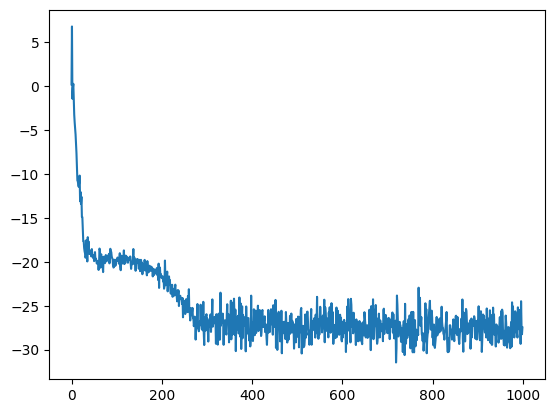

In [52]:
plt.plot(loss)

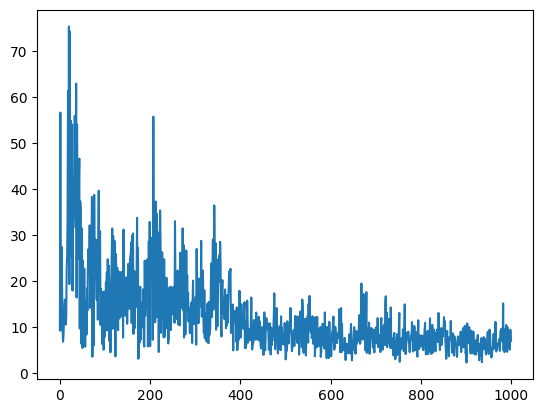

In [53]:
plt.plot(grad_norm)

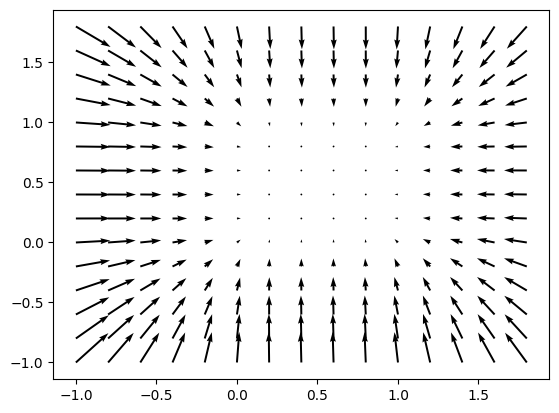

In [54]:
g, s = score.score_approx(-1, 2, -1, 2, 0.2)
g, s = g.numpy().T, s.numpy().T
plt.quiver(g[0], g[1], s[0], s[1])

In [55]:
init_samples = standard_gaussian_2d().sample((1000, ))
samples = score.sample_langevin(
	init_samples = init_samples,
	n_steps = 1000,
	epsilon = 0.1
)

100%|██████████| 1000/1000 [00:00<00:00, 1513.88it/s]


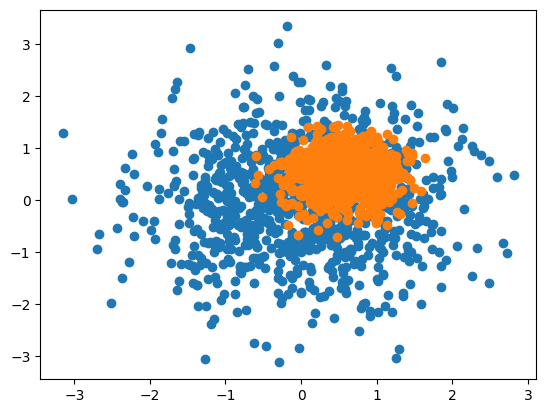

In [56]:
init_samples = init_samples.numpy().T
samples = samples.numpy().T
plt.scatter(init_samples[0], init_samples[1])
plt.scatter(samples[0], samples[1])